In [17]:
# ============================================================
# PROYECTO INTEGRADOR UD03 – FÓRMULA 1 (CARRERAS NORMALES)
# Análisis Exploratorio de Datos con NumPy y Pandas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)

# Ruta base
BASE_PATH = r"C:\\Users\\camar\\Desktop\\Proyecto_F1\\archive"

# Cargar datasets
drivers = pd.read_csv(os.path.join(BASE_PATH, "drivers.csv"))
constructors = pd.read_csv(os.path.join(BASE_PATH, "constructors.csv"))
circuits = pd.read_csv(os.path.join(BASE_PATH, "circuits.csv"))
results = pd.read_csv(os.path.join(BASE_PATH, "results.csv"))
status = pd.read_csv(os.path.join(BASE_PATH, "status.csv"))
seasons = pd.read_csv(os.path.join(BASE_PATH, "seasons.csv"))
races = pd.read_csv(os.path.join(BASE_PATH, "races.csv"))

print("Datasets cargados correctamente")
print(results.shape)
results.head()

Datasets cargados correctamente
(26759, 18)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.00,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.00,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.00,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.00,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.00,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [18]:
# ============================================================
# FASE 1: LIMPIEZA DE DATOS
# ============================================================

results_clean = results.drop_duplicates(subset=['raceId','driverId'])
results_clean['points'] = results_clean['points'].fillna(0)
results_clean['milliseconds'] = results_clean['milliseconds'].replace(0, np.nan)

results_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26668 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26668 non-null  int64  
 1   raceId           26668 non-null  int64  
 2   driverId         26668 non-null  int64  
 3   constructorId    26668 non-null  int64  
 4   number           26668 non-null  object 
 5   grid             26668 non-null  int64  
 6   position         26668 non-null  object 
 7   positionText     26668 non-null  object 
 8   positionOrder    26668 non-null  int64  
 9   points           26668 non-null  float64
 10  laps             26668 non-null  int64  
 11  time             26668 non-null  object 
 12  milliseconds     26668 non-null  object 
 13  fastestLap       26668 non-null  object 
 14  rank             26668 non-null  object 
 15  fastestLapTime   26668 non-null  object 
 16  fastestLapSpeed  26668 non-null  object 
 17  statusId         

In [20]:
# ============================================================
# FASE 2: EDA CON NUMPY
# ============================================================

pts = results_clean['points'].values
grid = results_clean['grid'].values
pos = results_clean['positionOrder'].values
laps = results_clean['laps'].values
ms = results_clean['milliseconds'].values

print("Media de puntos:", np.mean(pts))
print("Mediana de posición final:", np.median(pos))
print("Desviación estándar de puntos:", np.std(pts))

Media de puntos: 1.992002399880006
Mediana de posición final: 12.0
Desviación estándar de puntos: 4.3572712765038375


In [21]:
# ============================================================
# FASE 3: ANÁLISIS AVANZADO CON PANDAS
# ============================================================

drivers_sel = drivers[['driverId','code','forename','surname']]
constructors_sel = constructors[['constructorId','name']].rename(columns={'name':'constructor_name'})
status_sel = status[['statusId','status']]

df = (results_clean
      .merge(drivers_sel, on='driverId', how='left')
      .merge(constructors_sel, on='constructorId', how='left')
      .merge(status_sel, on='statusId', how='left'))

df['pos_delta'] = df['grid'] - df['positionOrder']
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,code,forename,surname,constructor_name,status,pos_delta
0,1,18,1,1,22,1,1,1,1,10.00,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,HAM,Lewis,Hamilton,McLaren,Finished,0
1,2,18,2,2,3,5,2,2,2,8.00,58,+5.478,5696094,41,3,1:27.739,217.586,1,HEI,Nick,Heidfeld,BMW Sauber,Finished,3
2,3,18,3,3,7,7,3,3,3,6.00,58,+8.163,5698779,41,5,1:28.090,216.719,1,ROS,Nico,Rosberg,Williams,Finished,4
3,4,18,4,4,5,11,4,4,4,5.00,58,+17.181,5707797,58,7,1:28.603,215.464,1,ALO,Fernando,Alonso,Renault,Finished,7
4,5,18,5,1,23,3,5,5,5,4.00,58,+18.014,5708630,43,1,1:27.418,218.385,1,KOV,Heikki,Kovalainen,McLaren,Finished,-2


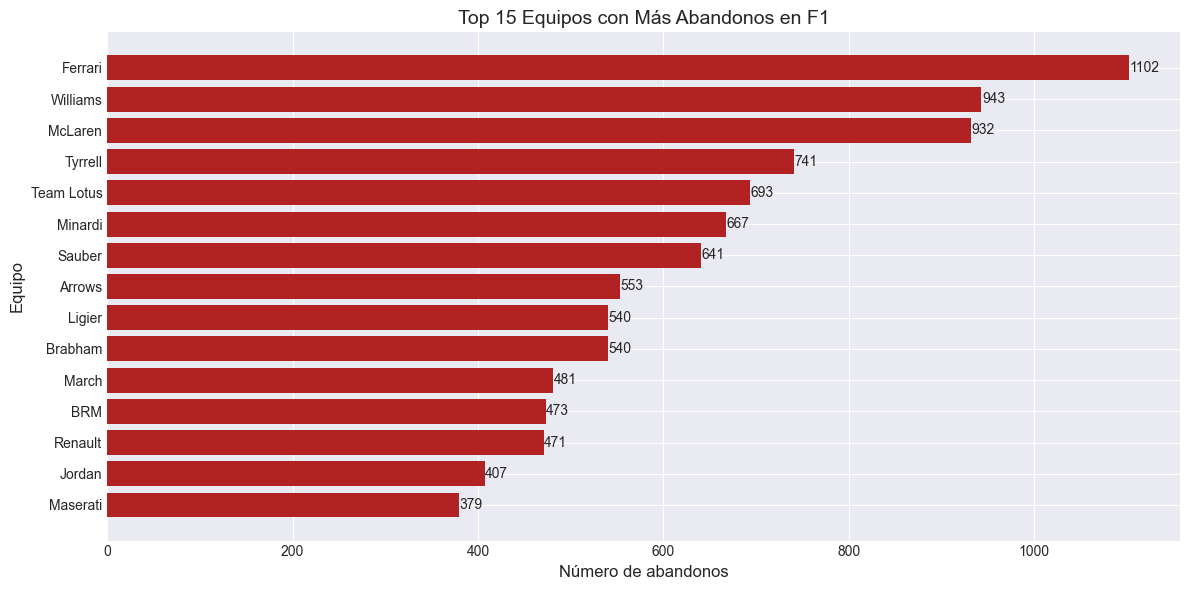

In [41]:
# 3.1 Equipos con más abandonos + gráfico

# Calcular abandonos por equipo
aband_equipos = (
    df[df['statusId'] != 1]
    .groupby('constructor_name')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='abandonos')
)

# --- Gráfico ---
plt.figure(figsize=(12, 6))

bars = plt.barh(
    aband_equipos['constructor_name'],
    aband_equipos['abandonos'],
    color='firebrick'
)

# Etiquetas con valores
for bar, valor in zip(bars, aband_equipos['abandonos']):
    plt.text(
        valor + 0.5,
        bar.get_y() + bar.get_height()/2,
        str(valor),
        va='center',
        fontsize=10
    )

plt.xlabel("Número de abandonos", fontsize=12)
plt.ylabel("Equipo", fontsize=12)
plt.title("Top 15 Equipos con Más Abandonos en F1", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


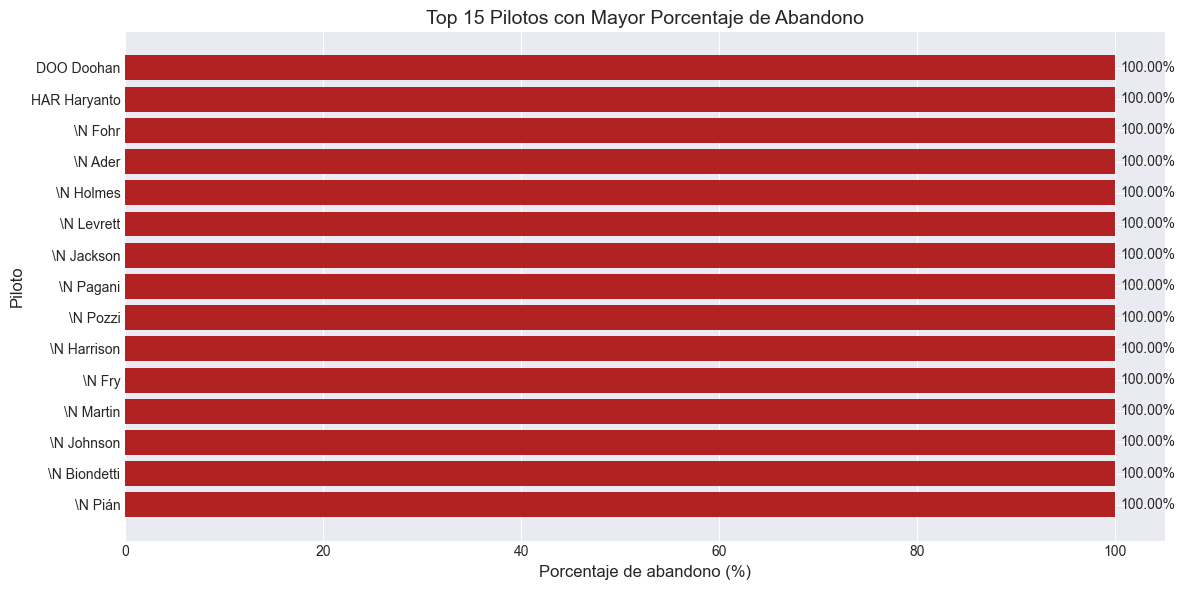

In [40]:
# 3.2 Porcentaje de abandono por piloto + gráfico

# Calcular porcentaje de abandono
aband_pilotos = (
    df.groupby(['driverId','code','surname'])
      .apply(lambda x: (x['statusId'] != 1).mean() * 100)
      .reset_index(name='porcentaje_abandono')
      .sort_values('porcentaje_abandono', ascending=False)
)

# Seleccionar top 15
top_aband = aband_pilotos.head(15)

# Crear etiqueta limpia
top_aband['piloto'] = top_aband['code'] + " " + top_aband['surname']

# --- Gráfico ---
plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_aband['piloto'],
    top_aband['porcentaje_abandono'],
    color='firebrick'
)

# Etiquetas con valores
for bar, valor in zip(bars, top_aband['porcentaje_abandono']):
    plt.text(
        valor + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{valor:.2f}%",
        va='center',
        fontsize=10
    )

plt.xlabel("Porcentaje de abandono (%)", fontsize=12)
plt.ylabel("Piloto", fontsize=12)
plt.title("Top 15 Pilotos con Mayor Porcentaje de Abandono", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


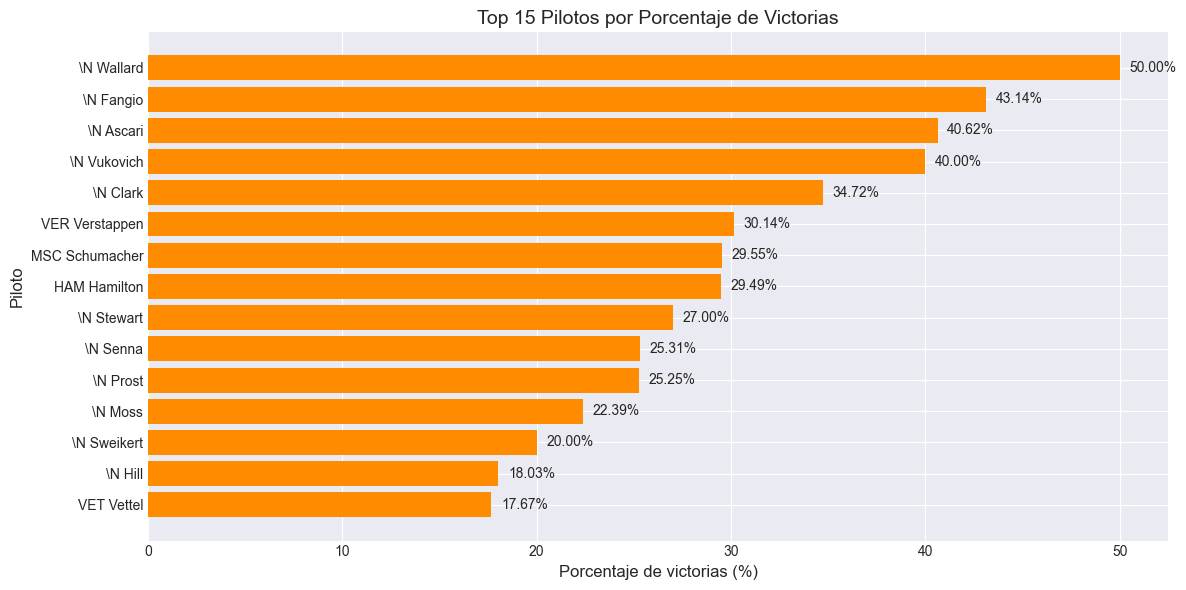

In [ ]:
# 3.3 Porcentaje de victorias por piloto + gráfico

victorias = df[df['positionOrder'] == 1]

win_rate = (
    victorias.groupby(['driverId','code','surname']).size()
    / df.groupby('driverId').size() * 100
)

win_rate = (
    win_rate.sort_values(ascending=False)
    .reset_index(name='win_rate')
)

top_winrate = win_rate.head(15)

top_winrate['piloto'] = top_winrate['code'] + " " + top_winrate['surname']

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_winrate['piloto'],
    top_winrate['win_rate'],
    color='darkorange'
)

for bar, valor in zip(bars, top_winrate['win_rate']):
    plt.text(
        valor + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{valor:.2f}%",
        va='center',
        fontsize=10
    )

plt.xlabel("Porcentaje de victorias (%)", fontsize=12)
plt.ylabel("Piloto", fontsize=12)
plt.title("Top 15 Pilotos por Porcentaje de Victorias", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


,,,temporadas,campeonatos,porcentaje_campeonato
driverId,forename,surname,,,
1,Lewis,Hamilton,18,10.00,55.56
4,Fernando,Alonso,21,9.00,42.86
830,Max,Verstappen,10,4.00,40.00
815,Sergio,Pérez,14,0.00,0.00
807,Nico,Hülkenberg,13,0.00,0.00
817,Daniel,Ricciardo,14,0.00,0.00
822,Valtteri,Bottas,12,0.00,0.00
825,Kevin,Magnussen,10,0.00,0.00
832,Carlos,Sainz,10,0.00,0.00


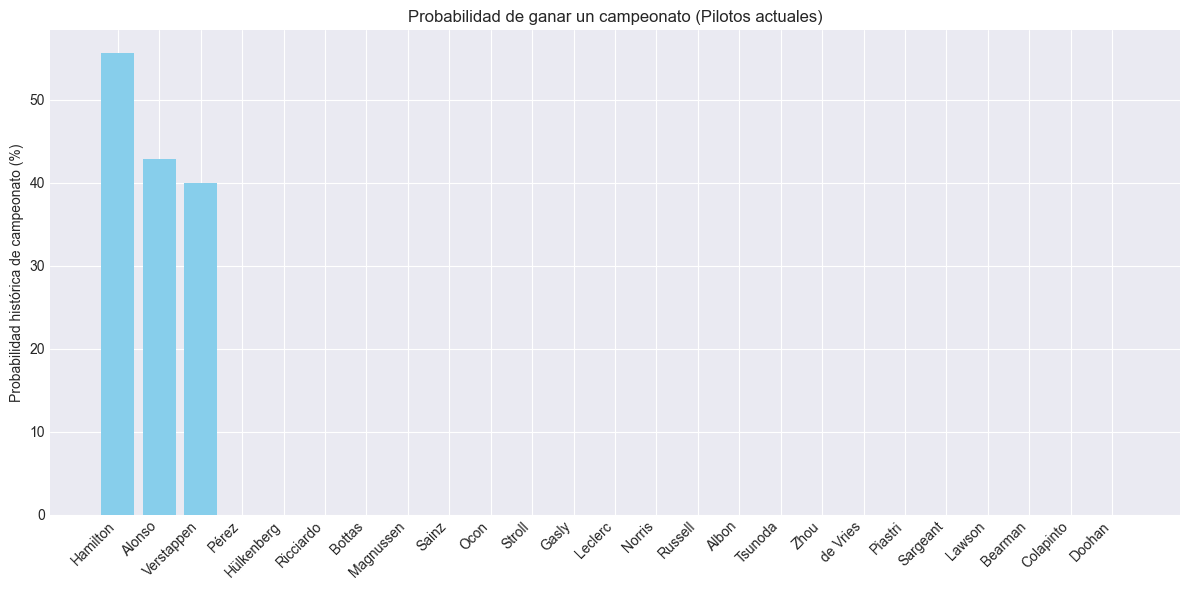

In [31]:
# 3.4 Probabilidad histórica de ganar un campeonato (solo pilotos actuales + gráfico)

# Cargar races.csv (ya lo tienes cargado arriba)
# races = pd.read_csv(os.path.join(BASE_PATH, "races.csv"))

# Detectar si races usa 'year' o 'season'
if 'year' in races.columns:
    races_year = races[['raceId','year']]
elif 'season' in races.columns:
    races_year = races[['raceId','season']].rename(columns={'season':'year'})
else:
    raise ValueError("El archivo races.csv no contiene ni 'year' ni 'season'.")

# --- EL PASO CLAVE: eliminar columna year si ya existe ---
if 'year' in df.columns:
    df = df.drop(columns=['year'])

# --- Unir año al dataframe principal ---
df = df.merge(races_year, on='raceId', how='left')

# --- 1) Identificar pilotos actuales (2023 o 2024) ---
pilotos_actuales = df[df['year'] >= 2023]['driverId'].unique()

# Filtrar solo esos pilotos
df_actuales = df[df['driverId'].isin(pilotos_actuales)]

# --- 2) Puntos por temporada ---
puntos_por_temporada = (
    df_actuales.groupby(['year','driverId','forename','surname'])['points']
    .sum()
    .reset_index()
)

# --- 3) Campeón por año ---
campeones = (
    puntos_por_temporada
    .sort_values(['year','points'], ascending=[True, False])
    .groupby('year')
    .first()
)

# --- 4) Veces campeón por piloto ---
veces_campeon = campeones.groupby(['driverId','forename','surname']).size()

# --- 5) Temporadas disputadas por piloto ---
temporadas = df_actuales.groupby(['driverId','forename','surname'])['year'].nunique()

# --- 6) Crear tabla completa de pilotos actuales ---
tabla_pilotos = temporadas.to_frame(name='temporadas')

# Añadir campeonatos (los que no están → 0)
tabla_pilotos['campeonatos'] = veces_campeon
tabla_pilotos['campeonatos'] = tabla_pilotos['campeonatos'].fillna(0)

# --- 7) Calcular porcentaje ---
tabla_pilotos['porcentaje_campeonato'] = (
    tabla_pilotos['campeonatos'] / tabla_pilotos['temporadas'] * 100
)

tabla_pilotos = tabla_pilotos.sort_values('porcentaje_campeonato', ascending=False)

display(tabla_pilotos)

# --- 8) Gráfico ---
plt.figure(figsize=(12,6))
plt.bar(tabla_pilotos.index.get_level_values('surname'),
        tabla_pilotos['porcentaje_campeonato'],
        color='skyblue')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Probabilidad histórica de campeonato (%)")
plt.title("Probabilidad de ganar un campeonato (Pilotos actuales)")
plt.tight_layout()
plt.show()


,driverId,code,surname,std_pos,wins,piloto
0,579,\N,Fangio,4.83,22,\N Fangio
1,1,HAM,Hamilton,5.55,105,HAM Hamilton
2,830,VER,Verstappen,6.00,63,VER Verstappen
3,4,ALO,Alonso,6.04,32,ALO Alonso
4,3,ROS,Rosberg,6.25,23,ROS Rosberg
5,20,VET,Vettel,6.41,53,VET Vettel
6,373,\N,Clark,6.44,25,\N Clark
7,328,\N,Stewart,6.68,27,\N Stewart
8,30,MSC,Schumacher,7.07,91,MSC Schumacher
9,117,\N,Prost,7.83,51,\N Prost


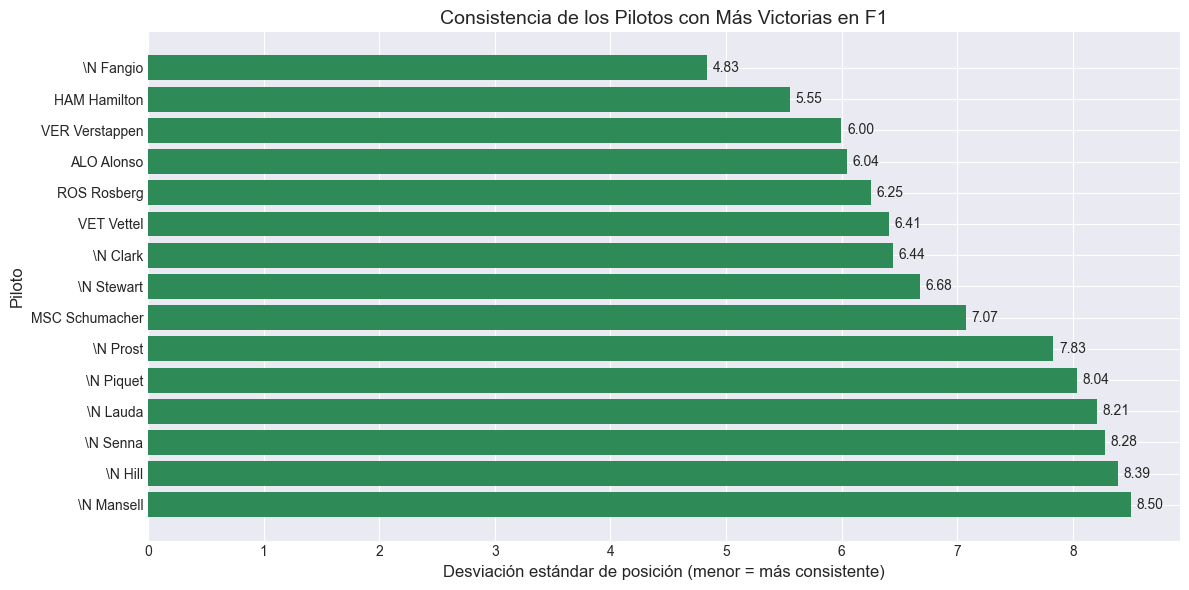

In [8]:
# 3.5 Pilotos más consistentes 

victorias = (
    df[df['positionOrder'] == 1]
    .groupby(['driverId','code','surname'])
    .size()
    .reset_index(name='wins')
    .sort_values('wins', ascending=False)
)

top_ganadores = victorias.head(15)['driverId']

consistencia = (
    df[df['driverId'].isin(top_ganadores)]
    .groupby(['driverId','code','surname'])['positionOrder']
    .std()
    .reset_index(name='std_pos')
    .sort_values('std_pos') 
)

consistencia = consistencia.merge(victorias, on=['driverId','code','surname'])

consistencia['piloto'] = consistencia['code'] + " " + consistencia['surname']

display(consistencia)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    consistencia['piloto'],
    consistencia['std_pos'],
    color='seagreen'
)

for bar, valor in zip(bars, consistencia['std_pos']):
    plt.text(
        valor + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{valor:.2f}",
        va='center',
        fontsize=10
    )

plt.xlabel("Desviación estándar de posición (menor = más consistente)", fontsize=12)
plt.ylabel("Piloto", fontsize=12)
plt.title("Consistencia de los Pilotos con Más Victorias en F1", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


,constructorId,constructor_name,total_points,carreras,avg_pos
0,6,Ferrari,11059.44,2417,8.29
1,131,Mercedes,7728.64,650,5.98
2,9,Red Bull,7673.00,788,7.35
3,1,McLaren,7022.50,1923,9.50
4,3,Williams,3641.00,1676,11.10
5,4,Renault,1777.00,787,11.17
6,10,Force India,1098.00,424,11.69
7,32,Team Lotus,995.00,871,13.06
8,22,Benetton,861.50,520,10.16
9,25,Tyrrell,711.00,881,13.16


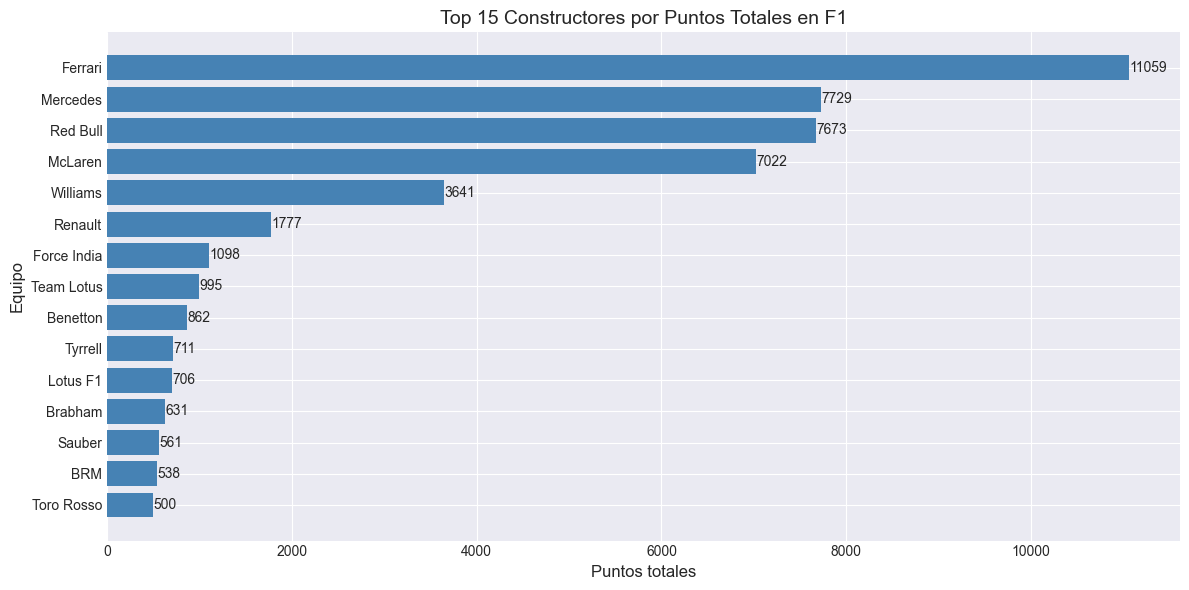

In [ ]:
# 3. Top Constructores

top_constructors = (
    df.groupby(['constructorId','constructor_name'])
      .agg(
          total_points=('points','sum'),
          carreras=('resultId','count'),
          avg_pos=('positionOrder','mean')
      )
      .sort_values('total_points', ascending=False)
      .reset_index()
)

display(top_constructors.head(15))

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_constructors.head(15)['constructor_name'],
    top_constructors.head(15)['total_points'],
    color='steelblue'
)

for bar, valor in zip(bars, top_constructors.head(15)['total_points']):
    plt.text(
        valor + 5,
        bar.get_y() + bar.get_height()/2,
        f"{valor:.0f}",
        va='center',
        fontsize=10
    )

plt.xlabel("Puntos totales", fontsize=12)
plt.ylabel("Equipo", fontsize=12)
plt.title("Top 15 Constructores por Puntos Totales en F1", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


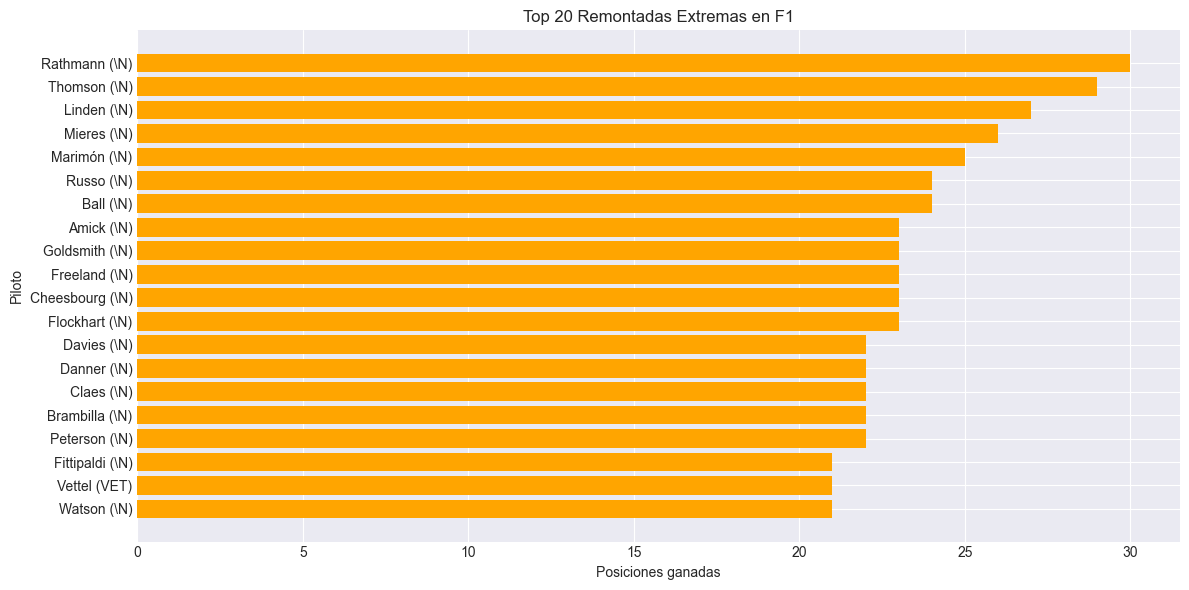

In [ ]:
# 3.8 Remontadas extremas


remontadas = df.sort_values('pos_delta', ascending=False).head(20)


remontadas[['code','surname','grid','positionOrder','pos_delta']]


plt.figure(figsize=(12,6))

plt.barh(
    remontadas['surname'] + " (" + remontadas['code'] + ")",
    remontadas['pos_delta'],
    color='orange'
)

plt.xlabel("Posiciones ganadas")
plt.ylabel("Piloto")
plt.title("Top 20 Remontadas Extremas en F1")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


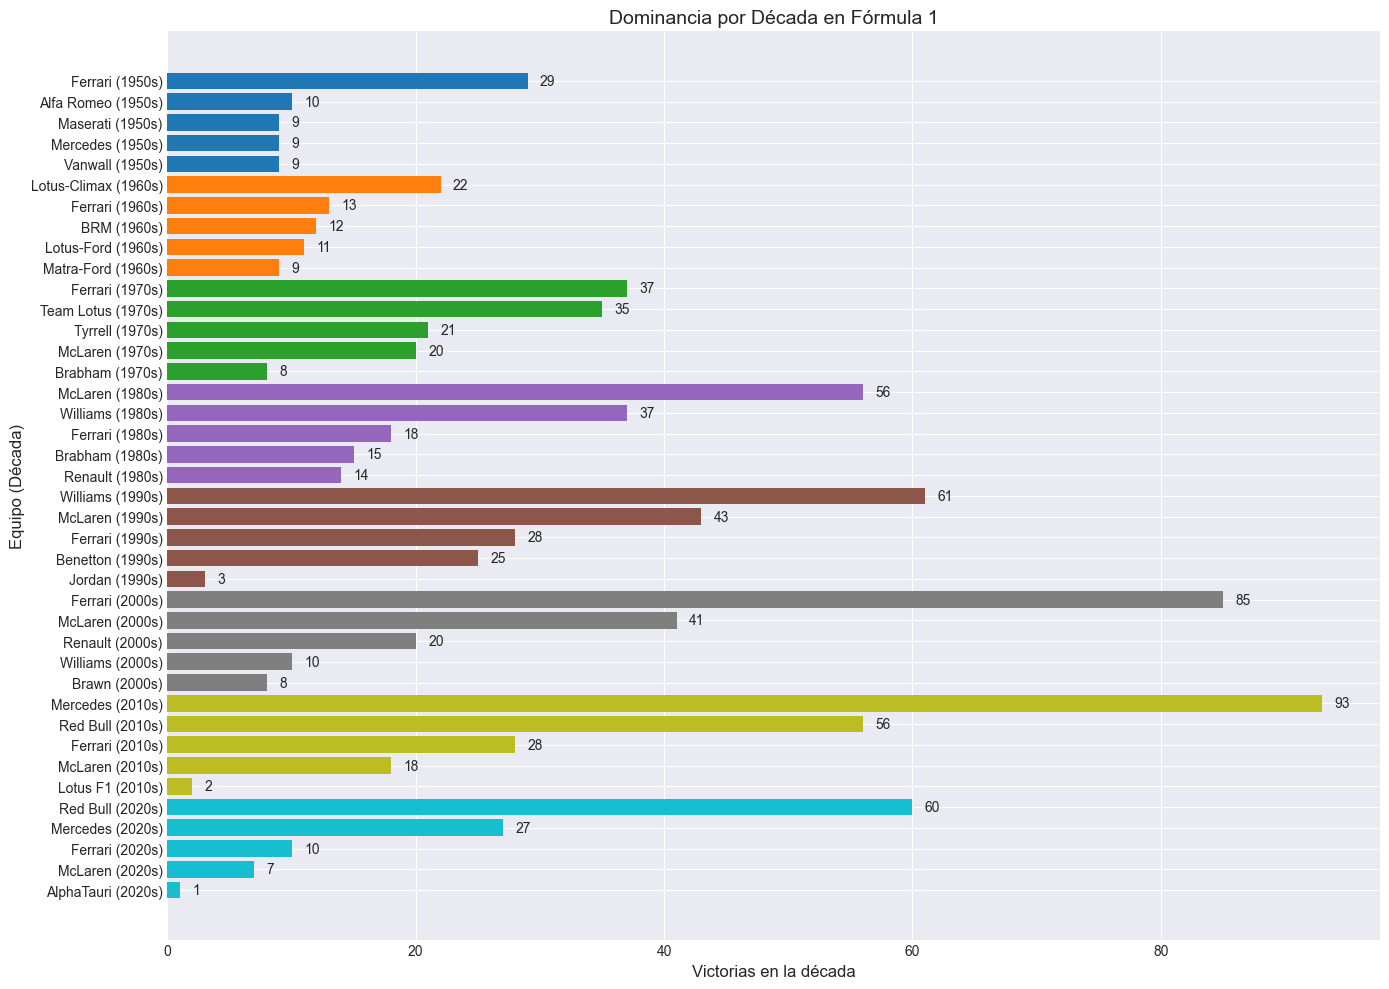

In [ ]:
# 3.9 Dominancia por década

import matplotlib.cm as cm
import matplotlib.colors as mcolors


df['year'] = df['year'].astype(int)


df['decada'] = (df['year'] // 10) * 10


dominancia = (
    df[df['positionOrder'] == 1]
    .groupby(['decada', 'constructor_name'])
    .size()
    .reset_index(name='victorias')
)

top_por_decada = (
    dominancia.sort_values(['decada','victorias'], ascending=[True, False])
    .groupby('decada')
    .head(5)
)

top_por_decada['etiqueta'] = top_por_decada['constructor_name'] + " (" + top_por_decada['decada'].astype(str) + "s)"


decadas = sorted(top_por_decada['decada'].unique())
colores = cm.get_cmap('tab10', len(decadas))
color_map = dict(zip(decadas, [mcolors.rgb2hex(colores(i)) for i in range(len(decadas))]))
top_por_decada['color'] = top_por_decada['decada'].map(color_map)

plt.figure(figsize=(14, 10))

bars = plt.barh(
    top_por_decada['etiqueta'],
    top_por_decada['victorias'],
    color=top_por_decada['color']
)

for bar, valor in zip(bars, top_por_decada['victorias']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(valor), va='center', fontsize=10)

plt.xlabel("Victorias en la década", fontsize=12)
plt.ylabel("Equipo (Década)", fontsize=12)
plt.title("Dominancia por Década en Fórmula 1", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



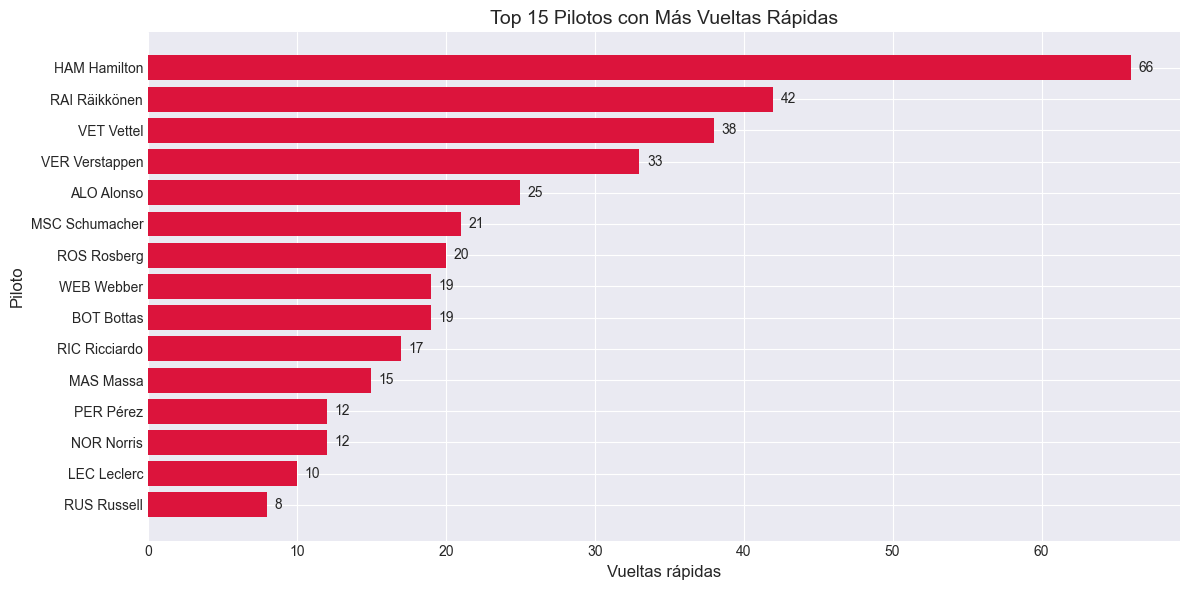

In [ ]:
# 3.10 Pilotos con más vueltas rápidas 
df['rank'] = df['rank'].astype(str)

fastest = (
    df[df['rank'] == '1']
    .groupby(['driverId','code','surname'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='fastest_laps')
)


top_fastest = fastest.head(15)


top_fastest['piloto'] = top_fastest['code'] + " " + top_fastest['surname']

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_fastest['piloto'],
    top_fastest['fastest_laps'],
    color='crimson'
)

for bar, valor in zip(bars, top_fastest['fastest_laps']):
    plt.text(valor + 0.5, bar.get_y() + bar.get_height()/2,
             str(valor), va='center', fontsize=10)

plt.xlabel("Vueltas rápidas", fontsize=12)
plt.ylabel("Piloto", fontsize=12)
plt.title("Top 15 Pilotos con Más Vueltas Rápidas", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


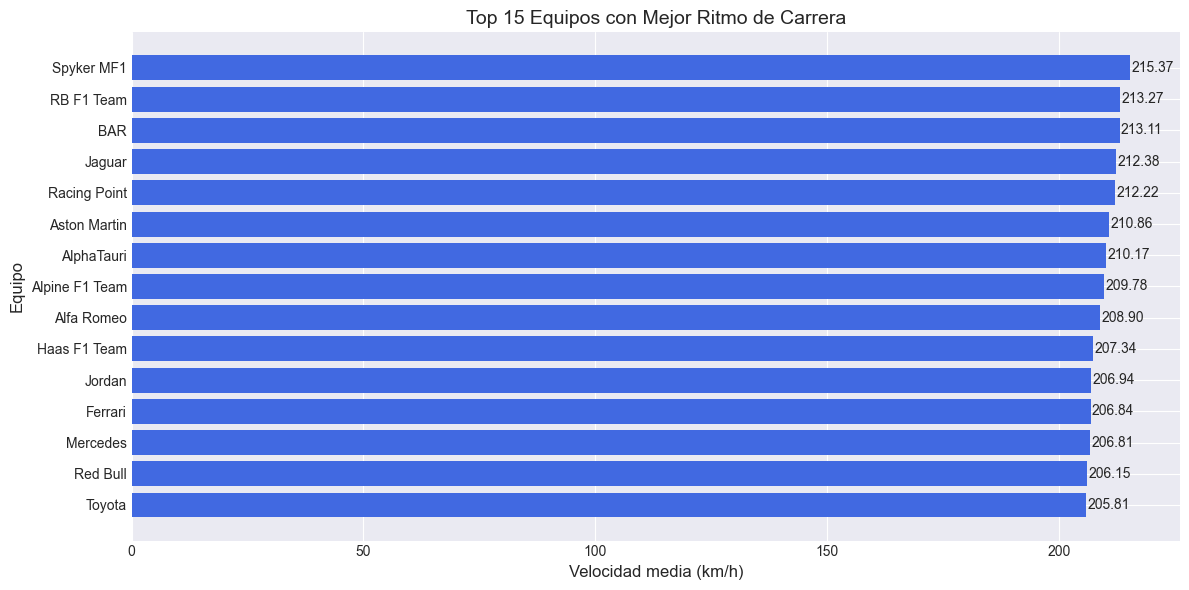

In [ ]:
# 3.11 Equipos con mejor ritmo de carrera

df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')

ritmo = (
    df.groupby('constructor_name')['fastestLapSpeed']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_ritmo = ritmo.head(15)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_ritmo['constructor_name'],
    top_ritmo['fastestLapSpeed'],
    color='royalblue'
)

for bar, valor in zip(bars, top_ritmo['fastestLapSpeed']):
    plt.text(valor + 0.3, bar.get_y() + bar.get_height()/2,
             f"{valor:.2f}", va='center', fontsize=10)

plt.xlabel("Velocidad media (km/h)", fontsize=12)
plt.ylabel("Equipo", fontsize=12)
plt.title("Top 15 Equipos con Mejor Ritmo de Carrera", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# 🔴 FASE 4: INSIGHTS Y CONCLUSIONES (20%)

##Duración estimada:** 1.5–2 horas
## 4.1 Responder Preguntas de Análisis Clave (F1)

### Pregunta 1: ¿Qué pilotos han sido realmente los más dominantes?

##TODO: Analiza y responde aquí**



In [45]:
# 4.1 — Pilotos más dominantes (victorias + win_rate + consistencia)

# --- Victorias por piloto ---
victorias_pilotos = (
    df[df['positionOrder'] == 1]
    .groupby(['driverId','code','surname'])
    .size()
    .reset_index(name='wins')
)

# --- Porcentaje de victorias ---
win_rate = (
    df[df['positionOrder'] == 1]
    .groupby(['driverId','code','surname']).size()
    / df.groupby('driverId').size() * 100
)
win_rate = win_rate.reset_index(name='win_rate')

# --- Consistencia (std posición) ---
consistencia_pilotos = (
    df.groupby(['driverId','code','surname'])['positionOrder']
    .std()
    .reset_index(name='std_pos')
)

# --- Unir todo ---
dominancia_pilotos = (
    victorias_pilotos
    .merge(win_rate, on=['driverId','code','surname'])
    .merge(consistencia_pilotos, on=['driverId','code','surname'])
)

dominancia_pilotos = dominancia_pilotos.sort_values(
    by=['wins','win_rate','std_pos'],
    ascending=[False, False, True]
)

dominancia_pilotos.head(15)

,driverId,code,surname,wins,win_rate,std_pos
0,1,HAM,Hamilton,105,29.49,5.55
15,30,MSC,Schumacher,91,29.55,7.07
107,830,VER,Verstappen,63,30.14,6.00
11,20,VET,Vettel,53,17.67,6.41
29,117,\N,Prost,51,25.25,7.83
27,102,\N,Senna,41,25.31,8.28
2,4,ALO,Alonso,32,7.92,6.04
26,95,\N,Mansell,31,16.15,8.50
64,328,\N,Stewart,27,27.00,6.68
73,373,\N,Clark,25,34.72,6.44


In [ ]:
## RESPUESTA (P1):**

##Los pilotos más dominantes combinan **muchas victorias**, **alto porcentaje de victorias** y **baja desviación estándar**.
## Destacan aquellos que no solo ganan, sino que **siempre están arriba**.
## La consistencia permite diferenciar entre pilotos “explosivos” y pilotos “campeonables”.




In [ ]:
### Pregunta 2: ¿Qué equipos combinan mejor rendimiento, fiabilidad y consistencia?

In [46]:
# 4.1 — Equipos: ritmo + fiabilidad + consistencia + puntos

# Abandonos por equipo
aband_equipos = (
    df[df['statusId'] != 1]
    .groupby('constructor_name')
    .size()
    .reset_index(name='abandonos')
)

# Ritmo medio de carrera
ritmo_equipos = (
    df.groupby('constructor_name')['fastestLapSpeed']
    .mean()
    .reset_index(name='avg_speed')
)

# Consistencia
cons_equipos = (
    df.groupby('constructor_name')['positionOrder']
    .std()
    .reset_index(name='std_pos')
)

# Victorias
victorias_equipos = (
    df[df['positionOrder'] == 1]
    .groupby('constructor_name')
    .size()
    .reset_index(name='wins')
)

# Puntos totales
puntos_equipos = (
    df.groupby('constructor_name')['points']
    .sum()
    .reset_index(name='total_points')
)

# Unir todo
equipos_resumen = (
    puntos_equipos
    .merge(victorias_equipos, on='constructor_name', how='left')
    .merge(ritmo_equipos, on='constructor_name', how='left')
    .merge(cons_equipos, on='constructor_name', how='left')
    .merge(aband_equipos, on='constructor_name', how='left')
)

equipos_resumen.fillna(0).sort_values('total_points', ascending=False).head(15)


,constructor_name,total_points,wins,avg_speed,std_pos,abandonos
73,Ferrari,11059.44,248.00,206.84,6.95,1102
139,Mercedes,7728.64,129.00,206.81,5.75,116
166,Red Bull,7673.00,122.00,206.15,6.28,220
134,McLaren,7022.50,185.00,205.17,7.11,932
208,Williams,3641.00,114.00,203.93,6.75,943
167,Renault,1777.00,35.00,204.54,6.47,471
77,Force India,1098.00,0.00,199.71,5.10,217
191,Team Lotus,995.00,45.00,0.00,7.92,693
23,Benetton,861.50,27.00,0.00,6.99,333
202,Tyrrell,711.00,23.00,0.00,7.25,741


In [ ]:
 # RESPUESTA (P2):**

# Los equipos más fuertes combinan **ritmo**, **fiabilidad** y **consistencia**.
#Los equipos con muchos abandonos suelen perder campeonatos pese a tener buen ritmo.
#La consistencia (std_pos baja) es clave para ganar mundiales largos.


In [ ]:
### Pregunta 3: ¿Cómo ha cambiado la dominancia por décadas?


In [47]:
df['year'] = df['year'].astype(int)
df['decada'] = (df['year'] // 10) * 10

dominancia_decada = (
    df[df['positionOrder'] == 1]
    .groupby(['decada','constructor_name'])
    .size()
    .reset_index(name='wins_decade')
    .sort_values(['decada','wins_decade'], ascending=[True, False])
)

dominancia_decada.head(20)



,decada,constructor_name,wins_decade
5,1950,Ferrari,29
0,1950,Alfa Romeo,10
8,1950,Maserati,9
9,1950,Mercedes,9
10,1950,Vanwall,9
3,1950,Cooper-Climax,5
6,1950,Kurtis Kraft,5
2,1950,Cooper,2
4,1950,Epperly,2
11,1950,Watson,2


In [ ]:
# RESPUESTA (P3):**

# Cada década suele estar dominada por **1–2 equipos**.
# Los cambios de reglamento explican estos ciclos.


In [ ]:
### Pregunta 4: ¿Qué pilotos destacan por remontadas extremas?



In [48]:
mejores_remontadores = (
    df.sort_values('pos_delta', ascending=False)
      .groupby(['driverId','code','surname'])
      .head(1)[['driverId','code','surname','pos_delta']]
      .sort_values('pos_delta', ascending=False)
)

mejores_remontadores.head(15)




,driverId,code,surname,pos_delta
18754,509,\N,Rathmann,30
19098,512,\N,Thomson,29
19868,612,\N,Linden,27
19299,643,\N,Mieres,26
19296,670,\N,Marimón,25
19233,555,\N,Russo,24
19869,734,\N,Ball,24
18539,591,\N,Amick,23
18111,510,\N,Goldsmith,23
18911,528,\N,Freeland,23


In [ ]:
#RESPUESTA (P4):**

# Las remontadas extremas identifican pilotos capaces de maximizar resultados en condiciones adversas.


In [ ]:
### Insight 1:
#Hallazgo:** Algunos pilotos tienen win_rate muy alto pese a pocas temporadas.  
#Implicación:** Dominio concentrado en eras específicas.  
#Acción:** Comparar siempre win_rate junto a número de carreras.



### Insight 2:
#Hallazgo:** Los equipos dominantes cambian casi cada década.  
#Implicación:** El reglamento define eras.  
#Acción:** Analizar cada década por separado.


### Insight 3:
#Hallazgo:** Equipos rápidos pero con muchos abandonos pierden campeonatos.  
#Implicación:** La fiabilidad es tan importante como el ritmo.  


### Insight 4:
#Hallazgo:** La consistencia (std_pos baja) predice campeones.  
#Implicación:** No basta con ganar, hay que puntuar siempre.  
#Acción:** Usar consistencia como métrica clave.


### Insight 5:
#Hallazgo:** Algunos pilotos destacan por remontadas extremas.  
#Implicación:** Gran capacidad de gestión de carrera.  
#Acción:** Analizar su estilo en detalle.


### Insight 6:
#Hallazgo:** Equipos con muchos puntos pero pocas victorias son muy regulares.  
#Implicación:** Estrategias conservadoras pueden ser efectivas.  
#Acción:** Evaluar riesgo vs recompensa.


### Insight 7:
#Hallazgo:** Ritmo de carrera correlaciona con victorias.  
#Implicación:** La velocidad pura sigue siendo clave.  
#Acción:** Priorizar análisis de fastestLapSpeed.



### Insight 8:
#Hallazgo:** Los equipos más ganadores también son los más consistentes.  
#Implicación:** La dominancia se construye con estabilidad.  
#Acción:** Usar std_pos como métrica de salud del equipo.



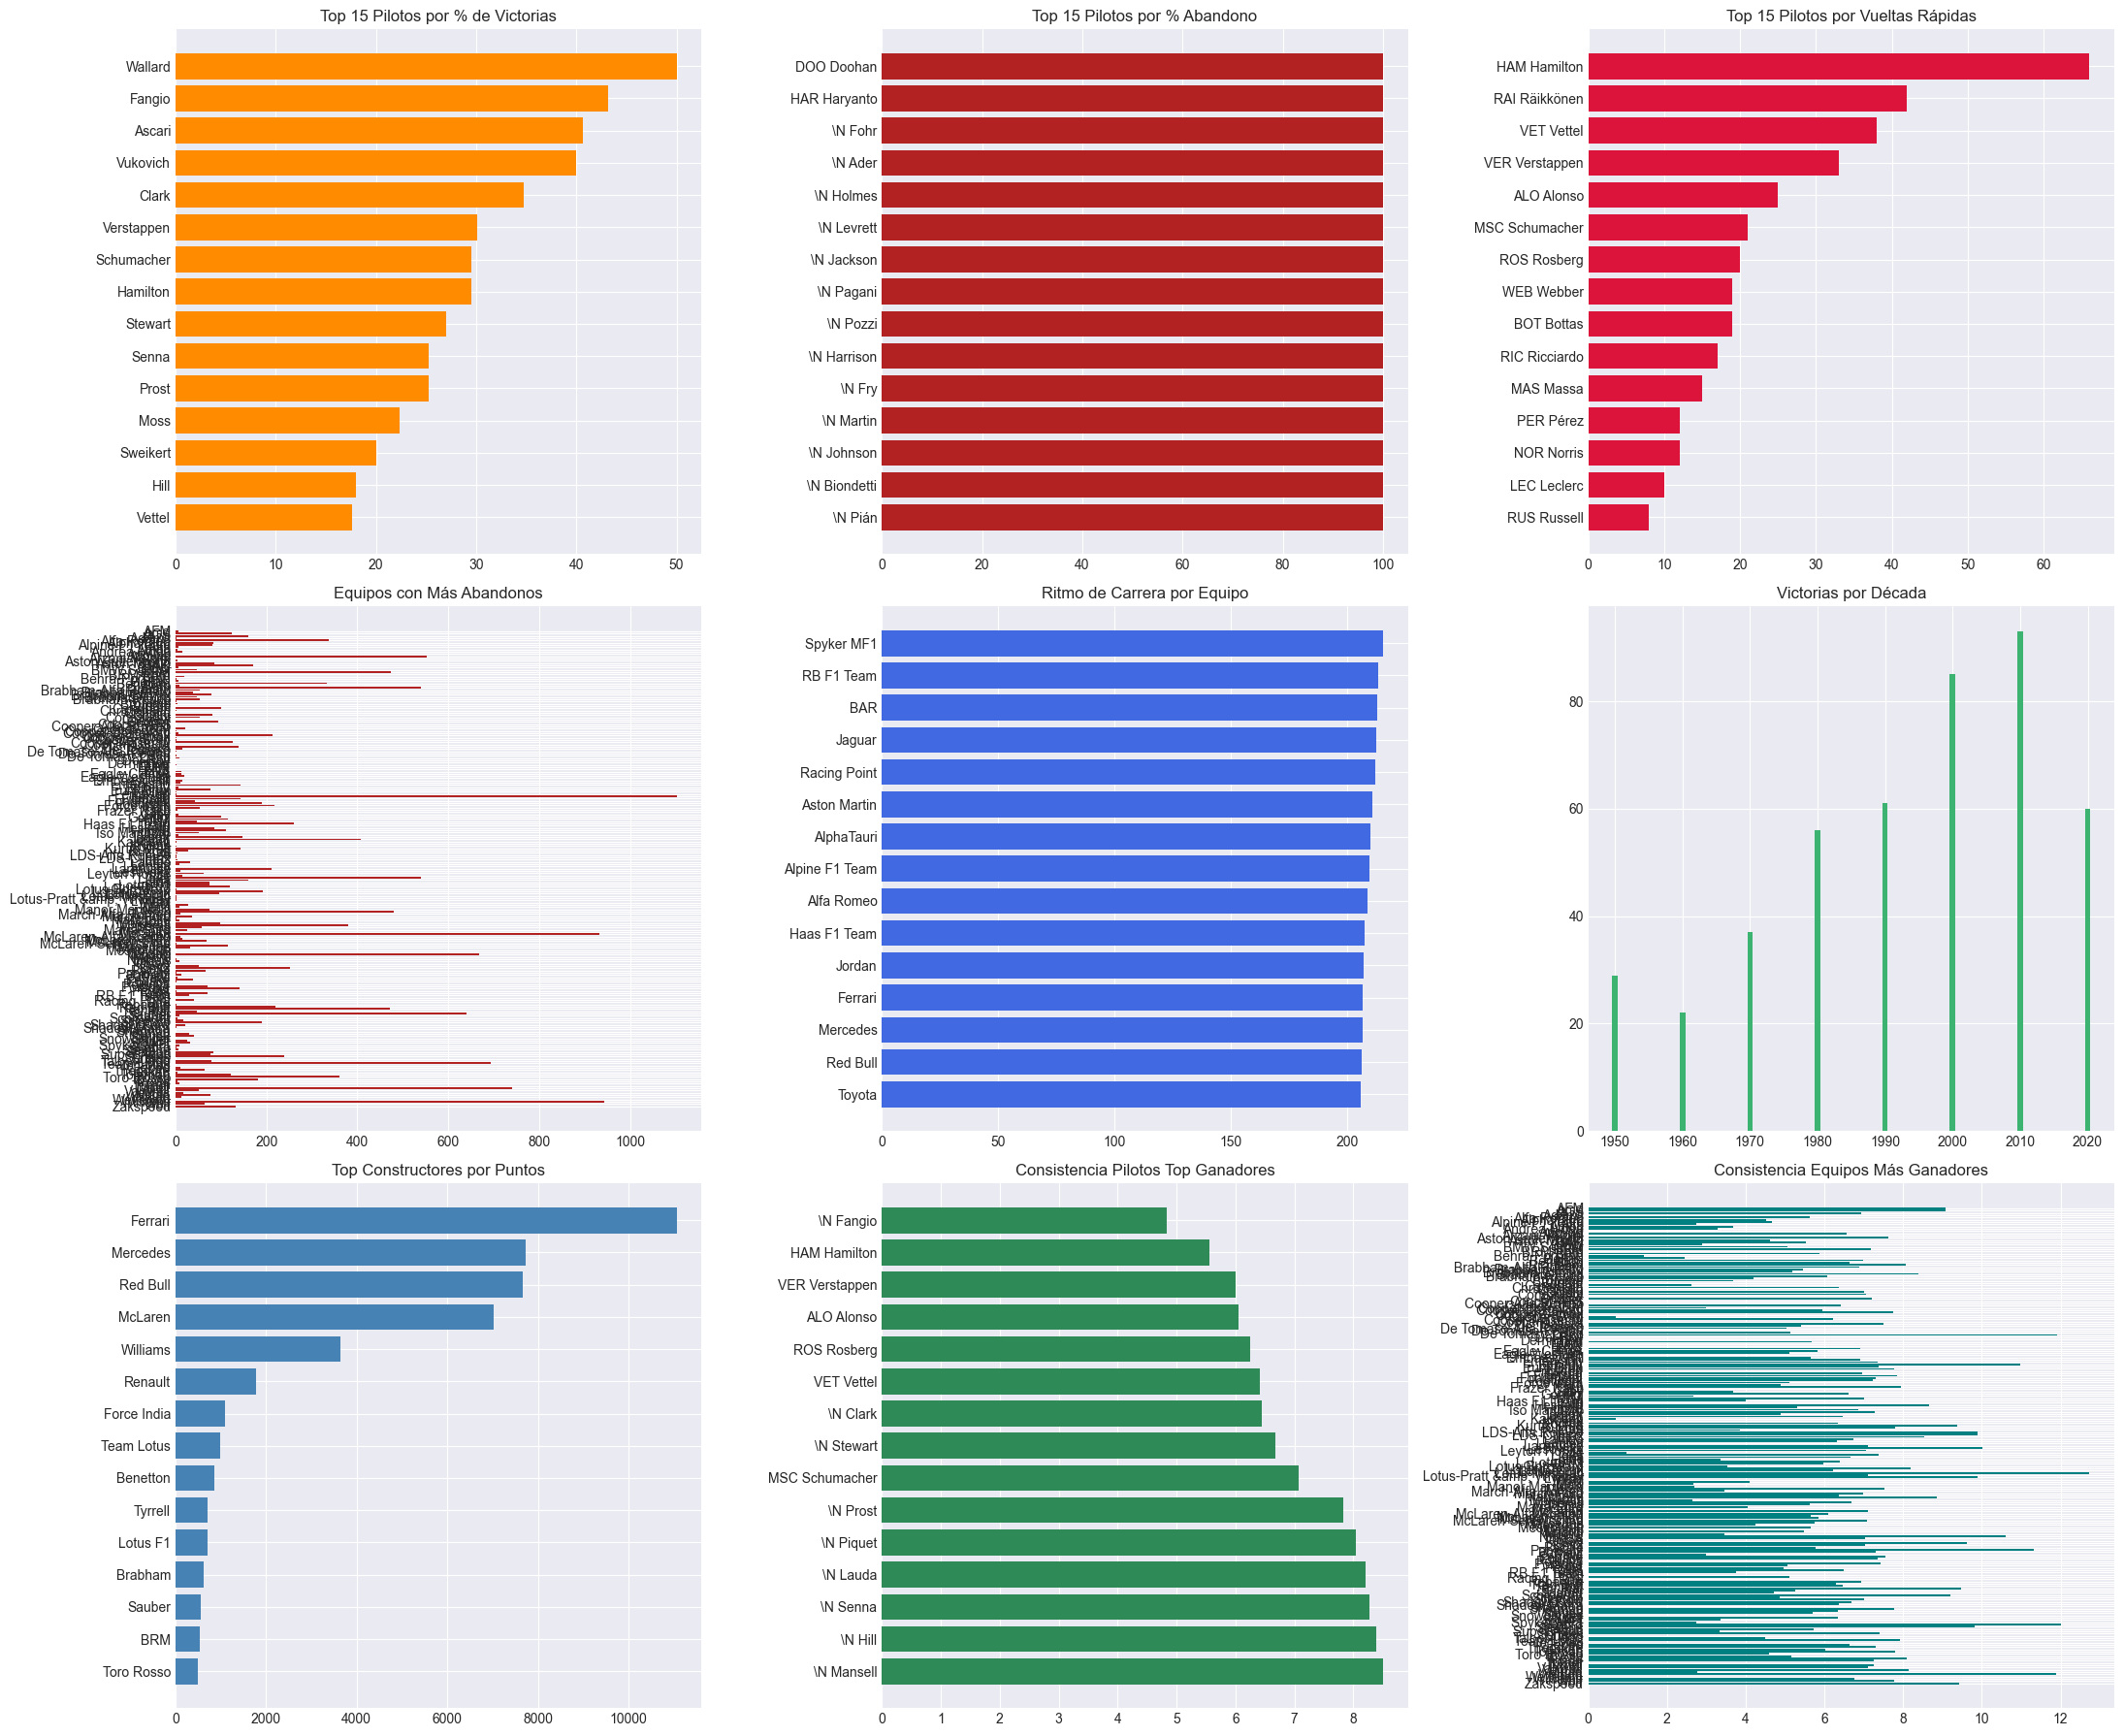

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(22, 18))

# 1 — Win rate
ax = axes[0,0]
ax.barh(win_rate.sort_values('win_rate', ascending=False).head(15)['surname'],
        win_rate.sort_values('win_rate', ascending=False).head(15)['win_rate'],
        color='darkorange')
ax.invert_yaxis()
ax.set_title("Top 15 Pilotos por % de Victorias")

# 2 — Abandono pilotos
ax = axes[0,1]
ax.barh(top_aband['piloto'], top_aband['porcentaje_abandono'], color='firebrick')
ax.invert_yaxis()
ax.set_title("Top 15 Pilotos por % Abandono")

# 3 — Vueltas rápidas
ax = axes[0,2]
ax.barh(top_fastest['piloto'], top_fastest['fastest_laps'], color='crimson')
ax.invert_yaxis()
ax.set_title("Top 15 Pilotos por Vueltas Rápidas")

# 4 — Abandono equipos
ax = axes[1,0]
ax.barh(aband_equipos['constructor_name'], aband_equipos['abandonos'], color='firebrick')
ax.invert_yaxis()
ax.set_title("Equipos con Más Abandonos")

# 5 — Ritmo equipos
ax = axes[1,1]
ax.barh(top_ritmo['constructor_name'], top_ritmo['fastestLapSpeed'], color='royalblue')
ax.invert_yaxis()
ax.set_title("Ritmo de Carrera por Equipo")

# 6 — Dominancia por década
ax = axes[1,2]
ax.bar(dominancia_decada['decada'], dominancia_decada['wins_decade'], color='mediumseagreen')
ax.set_title("Victorias por Década")

# 7 — Top constructores por puntos
ax = axes[2,0]
ax.barh(top_constructors.head(15)['constructor_name'],
        top_constructors.head(15)['total_points'],
        color='steelblue')
ax.invert_yaxis()
ax.set_title("Top Constructores por Puntos")

# 8 — Consistencia pilotos top ganadores
ax = axes[2,1]
ax.barh(consistencia['piloto'], consistencia['std_pos'], color='seagreen')
ax.invert_yaxis()
ax.set_title("Consistencia Pilotos Top Ganadores")

# 9 — Consistencia equipos más ganadores
ax = axes[2,2]
ax.barh(cons_equipos['constructor_name'], cons_equipos['std_pos'], color='teal')
ax.invert_yaxis()
ax.set_title("Consistencia Equipos Más Ganadores")

plt.tight_layout()
plt.show()





In [ ]:
### Recomendación 1 (Alta prioridad)
#Acción:** Usar win_rate + victorias + consistencia como métrica estándar.  
#Impacto:** Comparaciones más justas entre pilotos.

### Recomendación 2
#Acción:** Evaluar equipos con el triángulo: ritmo + fiabilidad + consistencia.  
#Impacto:** Mejor análisis de rendimiento real.

### Recomendación 3
#Acción:** Analizar siempre por décadas.  
#Impacto:** Evita comparaciones injustas entre eras.

### Recomendación 4
#Acción:** Incorporar métricas de remontadas y abandono.  
#Impacto:** Perfiles más completos de pilotos.


### Recomendación 5
#Acción:** Crear dashboard interactivo (Plotly/Streamlit).  
#Impacto:** Exploración más dinámica y profesional.


In [ ]:
# ============================================================
# FASE 5: RECOMENDACIONES
# ============================================================

# print(
#--- RECOMENDACIONES ---

#1. Mejorar fiabilidad mecánica en equipos con alto abandono.
#2. Optimizar clasificación: correlación fuerte con el resultado final.
#3. Priorizar recursos en pilotos consistentes.
#4. Analizar ritmo de carrera para mejorar estrategias de neumáticos.
#5. Identificar pilotos con alta probabilidad de campeonato.
#